In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
sns.set(style="whitegrid")
df = pd.read_csv("Online Retail.csv", encoding="ISO-8859-1")
print("Shape:", df.shape)
df.head()

Shape: (541909, 8)


,ï»¿InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [2]:
print(df.shape)
print(df.columns.tolist())
df.info()
df.isnull().sum()

(541909, 8)
['ï»¿InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ï»¿InvoiceNo  541909 non-null  str    
 1   StockCode     541909 non-null  str    
 2   Description   540455 non-null  str    
 3   Quantity      541909 non-null  int64  
 4   InvoiceDate   541909 non-null  str    
 5   UnitPrice     541909 non-null  float64
 6   CustomerID    406829 non-null  float64
 7   Country       541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


ï»¿InvoiceNo         0
StockCode            0
Description       1454
Quantity             0
InvoiceDate          0
UnitPrice            0
CustomerID      135080
Country              0
dtype: int64

In [3]:
df.describe(include='all')

,ï»¿InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,31-10-2011 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


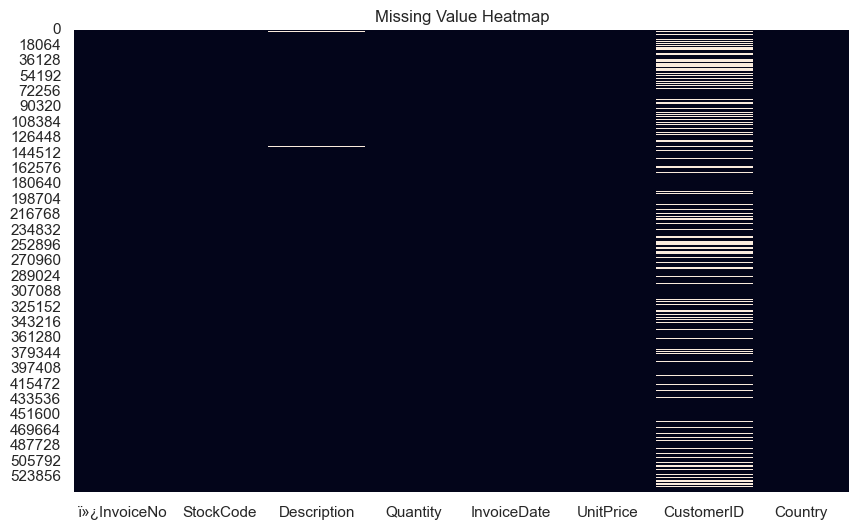

In [4]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

In [5]:
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)
print("Shape after removing missing customers:", df.shape)

Shape after removing missing customers: (406829, 8)


In [6]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)

In [7]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())

Duplicates before: 5225
Duplicates after: 0


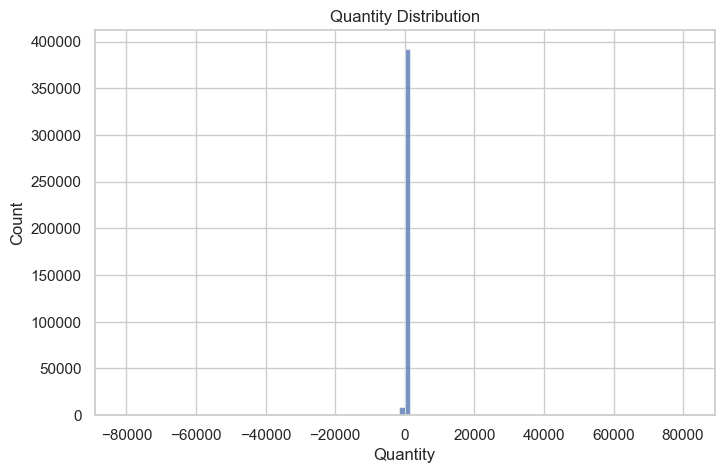

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Quantity'], bins=100)
plt.title("Quantity Distribution")
plt.show()

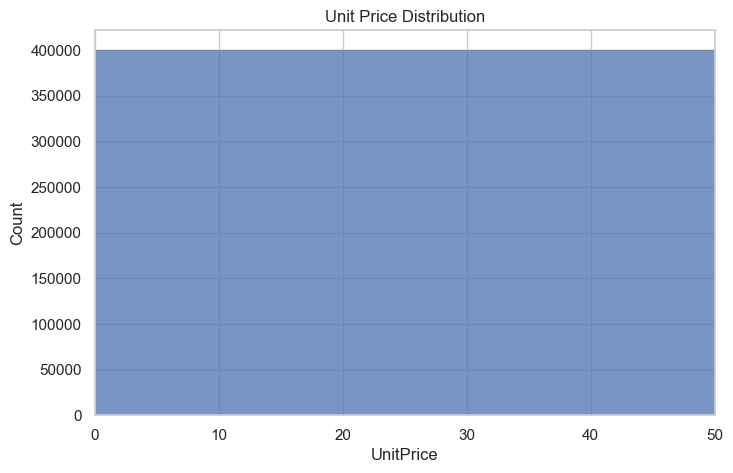

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['UnitPrice'], bins=100)
plt.xlim(0,50)
plt.title("Unit Price Distribution")
plt.show()

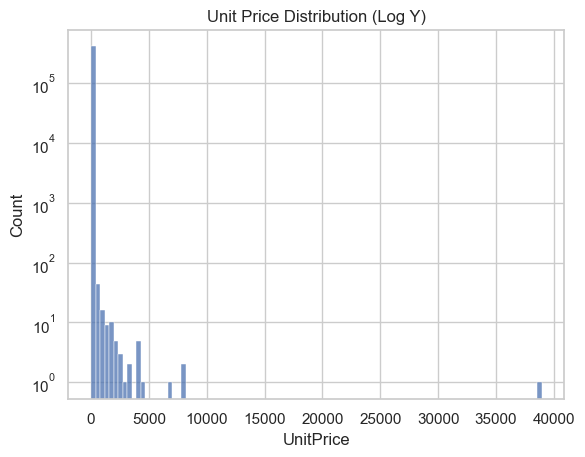

In [10]:
sns.histplot(df['UnitPrice'], bins=100)
plt.yscale('log')
plt.title("Unit Price Distribution (Log Y)")
plt.show()

In [11]:
df['IsReturn'] = df['Quantity'] < 0
print("Return %:", df['IsReturn'].mean())

Return %: 0.02209141343213713


In [12]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

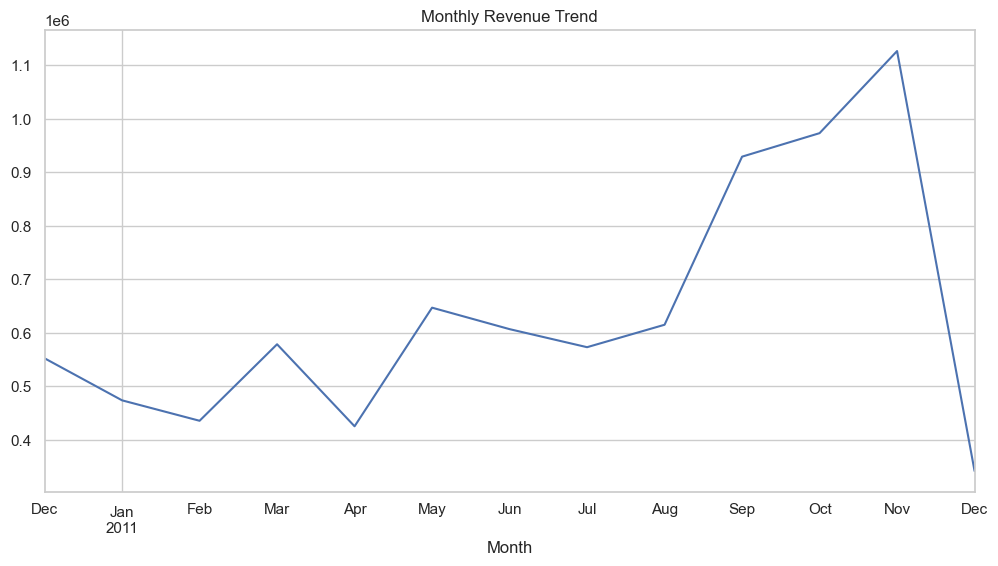

In [13]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['TotalPrice'].sum()
monthly_sales.plot(figsize=(12,6))
plt.title("Monthly Revenue Trend")
plt.show()

Unique Customers: 4372


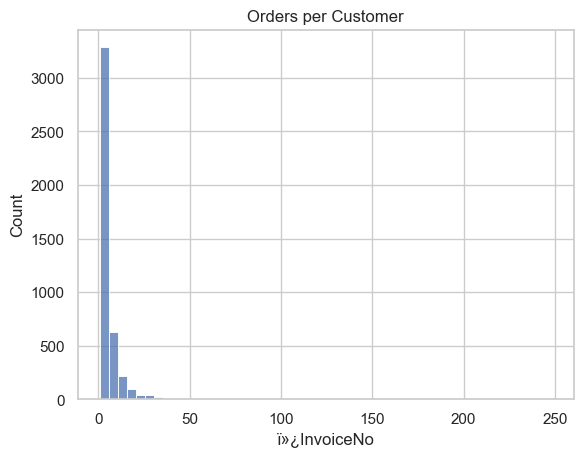

In [14]:
print("Unique Customers:", df['CustomerID'].nunique())
customer_orders = df.groupby('CustomerID')['ï»¿InvoiceNo'].nunique()
sns.histplot(customer_orders, bins=50)
plt.title("Orders per Customer")
plt.show()
# df.columns

In [15]:
# EDA concludes here

In [16]:
# start of RFM and behavioral Feature Engineerning

In [17]:
max_date = df['InvoiceDate'].max() # considering this as a reference for core RFM

In [18]:
# need recency,frequency,monetary
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (max_date - x.max()).days,  # Recency
    'ï»¿InvoiceNo': 'nunique',                           # Frequency
    'TotalPrice': 'sum'                                  # Monetary
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,325,2,0.00
12347,1,7,4310.00
12348,74,4,1797.24
12349,18,1,1757.55
12350,309,1,334.40


In [19]:
# Average Order Value=monetary/freq
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']

# Total Returns=count of quantity which is less than 0 inaccordance to customerID
returns = df[df['Quantity'] < 0].groupby('CustomerID')['Quantity'].count()
rfm['TotalReturns'] = returns

rfm['TotalReturns'] = rfm['TotalReturns'].fillna(0)

# Return Ratio=total/freq
rfm['ReturnRatio'] = rfm['TotalReturns'] / rfm['Frequency']

# Customer Lifetime
first_purchase = df.groupby('CustomerID')['InvoiceDate'].min()
last_purchase = df.groupby('CustomerID')['InvoiceDate'].max()
rfm['CustomerLifetime'] = (last_purchase - first_purchase).dt.days

In [20]:
rfm['LastPurchaseDate'] = last_purchase

In [21]:
churn = (max_date - last_purchase).dt.days > 90
rfm['churn'] = churn.astype(int)

In [22]:
rfm = rfm.fillna(0)
rfm.head()

,Recency,Frequency,Monetary,AvgOrderValue,TotalReturns,ReturnRatio,CustomerLifetime,LastPurchaseDate,churn
CustomerID,,,,,,,,,
12346,325,2,0.00,0.000000,1.0,0.5,0,2011-01-18 10:17:00,1
12347,1,7,4310.00,615.714286,0.0,0.0,365,2011-12-07 15:52:00,0
12348,74,4,1797.24,449.310000,0.0,0.0,282,2011-09-25 13:13:00,0
12349,18,1,1757.55,1757.550000,0.0,0.0,0,2011-11-21 09:51:00,0
12350,309,1,334.40,334.400000,0.0,0.0,0,2011-02-02 16:01:00,1


In [23]:
print("Customer-level dataset shape:", rfm.shape)
rfm['churn'].value_counts(normalize=True)

Customer-level dataset shape: (4372, 9)


churn
0    0.668344
1    0.331656
Name: proportion, dtype: float64

In [24]:
# rfm_sorted = rfm.sort_values('LastPurchaseDate')

In [25]:
# n = len(rfm_sorted)
# train_end = int(0.70 * n)
# val_end = int(0.85 * n)
# train = rfm_sorted.iloc[:train_end]
# val = rfm_sorted.iloc[train_end:val_end]
# test = rfm_sorted.iloc[val_end:]
# print(train.shape, val.shape, test.shape)

In [26]:
# X = rfm.select_dtypes(include=['int64', 'float64'])
# y = rfm['churn']
# X_train = train[features]
# y_train = train['churn']
# X_val = val[features]
# y_val = val['churn']
# X_test = test[features]
# y_test = test['churn']

# rfm_sorted = rfm.sort_values('LastPurchaseDate')

# features = rfm.select_dtypes(include=['int64', 'float64']).columns.drop('churn')

# train = rfm_sorted.iloc[:train_end]
# val = rfm_sorted.iloc[train_end:val_end]
# test = rfm_sorted.iloc[val_end:]

# X_train = train[features]
# y_train = train['churn']

# X_val = val[features]
# y_val = val['churn']

# X_test = test[features]
# y_test = test['churn']

# Sort first
# rfm_sorted = rfm.sort_values('LastPurchaseDate')

# n = len(rfm_sorted)
# train_end = int(0.70 * n)
# val_end = int(0.85 * n)

# train = rfm_sorted.iloc[:train_end]
# val = rfm_sorted.iloc[train_end:val_end]
# test = rfm_sorted.iloc[val_end:]

# # Strict numeric-only features (from split sets)
# X_train = train.select_dtypes(include=['int64', 'float64']).drop(columns=['churn'])
# y_train = train['churn']

# X_val = val.select_dtypes(include=['int64', 'float64']).drop(columns=['churn'])
# y_val = val['churn']

# X_test = test.select_dtypes(include=['int64', 'float64']).drop(columns=['churn'])
# y_test = test['churn']

# print(X_train.columns)
# print(X_train.dtypes)


from sklearn.model_selection import train_test_split

X = rfm.select_dtypes(include=['int64','float64']).drop(columns=['churn','Recency'])
y = rfm['churn']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(y_train.value_counts())
print(y_val.value_counts())
print(y_test.value_counts())

churn
0    2045
1    1015
Name: count, dtype: int64
churn
0    438
1    218
Name: count, dtype: int64
churn
0    439
1    217
Name: count, dtype: int64


In [27]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("Any NaNs?", X_train.isnull().sum().sum())

X_train: (3060, 6)
y_train: (3060,)
Any NaNs? 0


In [28]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
val_probs = xgb_model.predict_proba(X_val)[:,1]
test_probs = xgb_model.predict_proba(X_test)[:,1]

print("Validation ROC-AUC:", roc_auc_score(y_val, val_probs))
print("Test ROC-AUC:", roc_auc_score(y_test, test_probs))

Validation ROC-AUC: 0.7539692513929035
Test ROC-AUC: 0.8092858717445388


In [29]:
rfm[['Recency','churn']].corr()

,Recency,churn
Recency,1.000000,0.859566
churn,0.859566,1.000000


In [30]:
!pip install catboost

In [31]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=300,
    depth=4,
    learning_rate=0.05,
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train, y_train)

val_probs_cat = cat_model.predict_proba(X_val)[:,1]
test_probs_cat = cat_model.predict_proba(X_test)[:,1]

print("CatBoost Validation ROC:", roc_auc_score(y_val, val_probs_cat))
print("CatBoost Test ROC:", roc_auc_score(y_test, test_probs_cat))

CatBoost Validation ROC: 0.7604363034644547
CatBoost Test ROC: 0.8145240019734838


In [32]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["XGBoost", "CatBoost"],
    "Validation_ROC": [
        roc_auc_score(y_val, val_probs),
        roc_auc_score(y_val, val_probs_cat)
    ],
    "Test_ROC": [
        roc_auc_score(y_test, test_probs),
        roc_auc_score(y_test, test_probs_cat)
    ]
})

comparison

,Model,Validation_ROC,Test_ROC
0,XGBoost,0.753969,0.809286
1,CatBoost,0.760436,0.814524


In [33]:
seeds = [0, 7, 21, 42, 99, 123, 777, 2024, 555, 888]
xgb_results = []
for seed in seeds:
    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=seed,
        eval_metric='logloss'
    )
    
    model.fit(X_train, y_train)
    
    val_probs = model.predict_proba(X_val)[:,1]
    test_probs = model.predict_proba(X_test)[:,1]
    
    val_auc = roc_auc_score(y_val, val_probs)
    test_auc = roc_auc_score(y_test, test_probs)
    
    xgb_results.append([seed, val_auc, test_auc])

xgb_df = pd.DataFrame(xgb_results, columns=['Seed','Validation_ROC','Test_ROC'])
xgb_df

,Seed,Validation_ROC,Test_ROC
0,0,0.753001,0.808226
1,7,0.755608,0.808089
2,21,0.749597,0.806929
3,42,0.753969,0.809286
4,99,0.752335,0.805050
5,123,0.747942,0.806116
6,777,0.753236,0.805948
7,2024,0.751634,0.805780
8,555,0.749712,0.809396
9,888,0.752791,0.808992


In [34]:
from catboost import CatBoostClassifier

cat_results = []

for seed in seeds:
    
    model = CatBoostClassifier(
        iterations=300,
        depth=4,
        learning_rate=0.05,
        random_seed=seed,
        verbose=0
    )
    
    model.fit(X_train, y_train)
    
    val_probs = model.predict_proba(X_val)[:,1]
    test_probs = model.predict_proba(X_test)[:,1]
    
    val_auc = roc_auc_score(y_val, val_probs)
    test_auc = roc_auc_score(y_test, test_probs)
    
    cat_results.append([seed, val_auc, test_auc])

cat_df = pd.DataFrame(cat_results, columns=['Seed','Validation_ROC','Test_ROC'])
cat_df

,Seed,Validation_ROC,Test_ROC
0,0,0.763453,0.816928
1,7,0.763473,0.818104
2,21,0.761489,0.815248
3,42,0.760436,0.814524
4,99,0.761285,0.818093
5,123,0.764081,0.810866
6,777,0.765076,0.812949
7,2024,0.760960,0.813459
8,555,0.763112,0.813495
9,888,0.762300,0.812829


In [35]:
print("XGBoost Mean Test ROC:", xgb_df['Test_ROC'].mean())
print("XGBoost Std Test ROC:", xgb_df['Test_ROC'].std())

print("\nCatBoost Mean Test ROC:", cat_df['Test_ROC'].mean())
print("CatBoost Std Test ROC:", cat_df['Test_ROC'].std())

XGBoost Mean Test ROC: 0.8073811448306267
XGBoost Std Test ROC: 0.0016108972729557125

CatBoost Mean Test ROC: 0.8146494441703493
CatBoost Std Test ROC: 0.002418158182303492


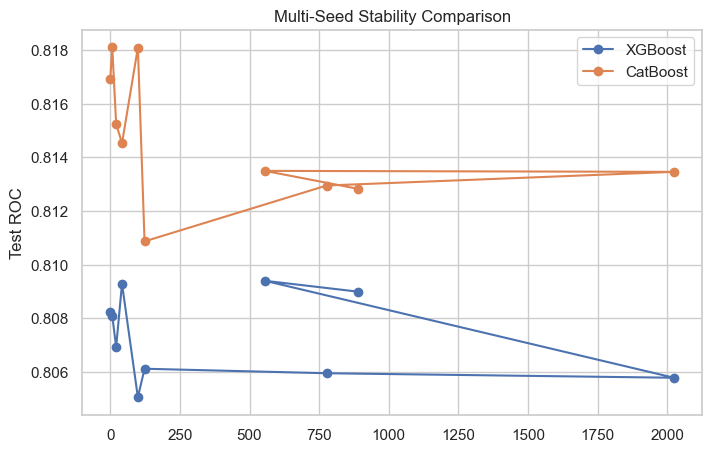

In [36]:
plt.figure(figsize=(8,5))
plt.plot(xgb_df['Seed'], xgb_df['Test_ROC'], marker='o', label='XGBoost')
plt.plot(cat_df['Seed'], cat_df['Test_ROC'], marker='o', label='CatBoost')
plt.legend()
plt.title("Multi-Seed Stability Comparison")
plt.ylabel("Test ROC")
plt.show()

In [37]:
!pip install shap

In [38]:
import shap
import matplotlib.pyplot as plt

shap.initjs()

In [39]:
from xgboost import XGBClassifier

final_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    # use_label_encoder=False
)

In [40]:
final_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [41]:
from sklearn.metrics import roc_auc_score, classification_report

val_probs = final_model.predict_proba(X_val)[:, 1]
test_probs = final_model.predict_proba(X_test)[:, 1]

print("Validation ROC-AUC:", roc_auc_score(y_val, val_probs))
print("Test ROC-AUC:", roc_auc_score(y_test, test_probs))

Validation ROC-AUC: 0.7539692513929035
Test ROC-AUC: 0.8092858717445388


In [42]:
import joblib
joblib.dump(final_model, "xgboost_churn_model.pkl")

['xgboost_churn_model.pkl']

In [43]:
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])
final_model.fit(X_train_full, y_train_full)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [44]:
joblib.dump(final_model, "xgboost_churn_model.pkl")

['xgboost_churn_model.pkl']

In [45]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

In [46]:
print(type(shap_values))
print(len(shap_values))
print(X_test.shape)

<class 'numpy.ndarray'>
656
(656, 6)


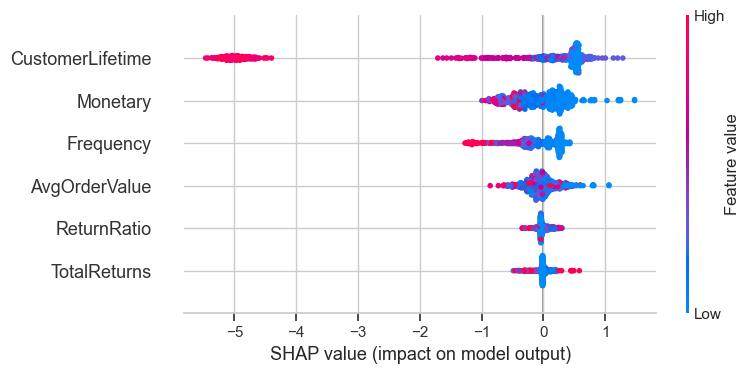

In [47]:
shap.summary_plot(shap_values, X_test)

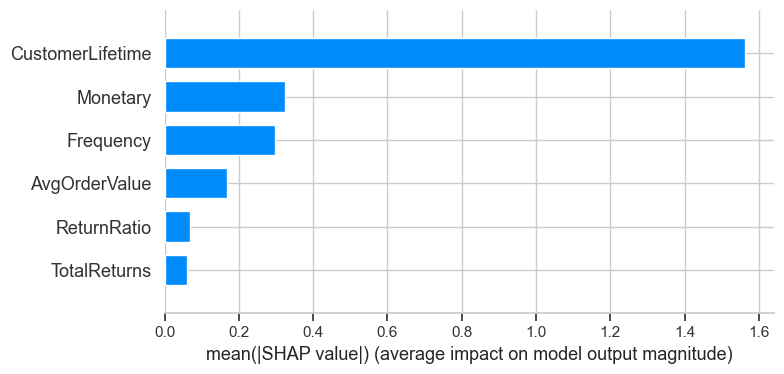

In [48]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

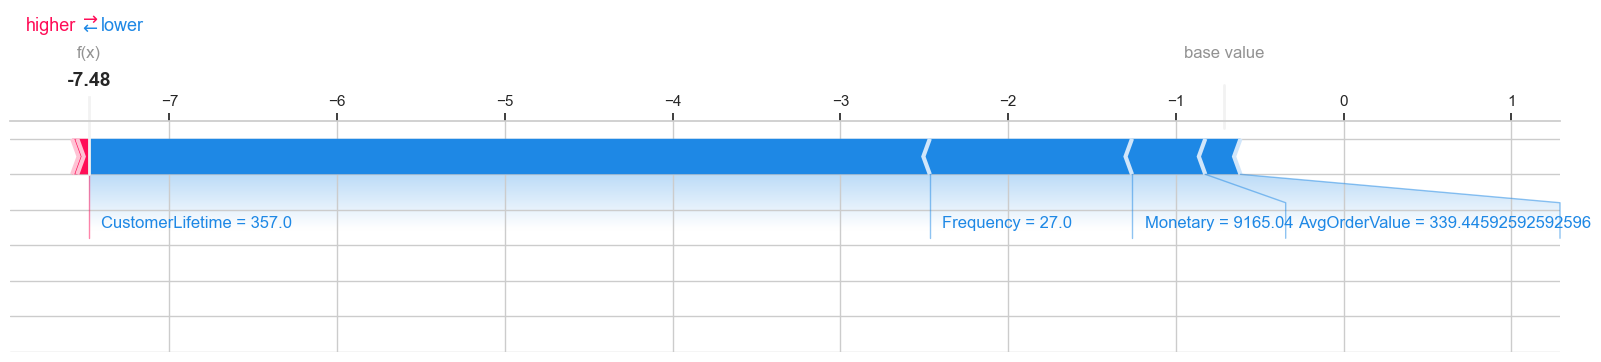

In [49]:
idx = 10

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test.iloc[idx],
    matplotlib=True
)

In [50]:
def get_top_features(index, top_n=3):
    shap_vals = shap_values[index]
    feature_names = X_test.columns
    
    feature_impact = list(zip(feature_names, shap_vals))
    feature_impact.sort(key=lambda x: abs(x[1]), reverse=True)
    
    return feature_impact[:top_n]

get_top_features(10)

[('CustomerLifetime', np.float32(-5.013886)),
 ('Frequency', np.float32(-1.205232)),
 ('Monetary', np.float32(-0.43692565))]

In [51]:
pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 6.4 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [52]:
from lightgbm import LGBMClassifier

In [58]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

lgb_model.fit(X_train, y_train)

val_probs_lgb = lgb_model.predict_proba(X_val)[:,1]
test_probs_lgb = lgb_model.predict_proba(X_test)[:,1]

[LightGBM] [Info] Number of positive: 1015, number of negative: 2045
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000196 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 929
[LightGBM] [Info] Number of data points in the train set: 3060, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.331699 -> initscore=-0.700509
[LightGBM] [Info] Start training from score -0.700509
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [59]:
y_pred_proba = lgb_model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("LightGBM ROC-AUC:", roc_auc)

LightGBM ROC-AUC: 0.801974533659448


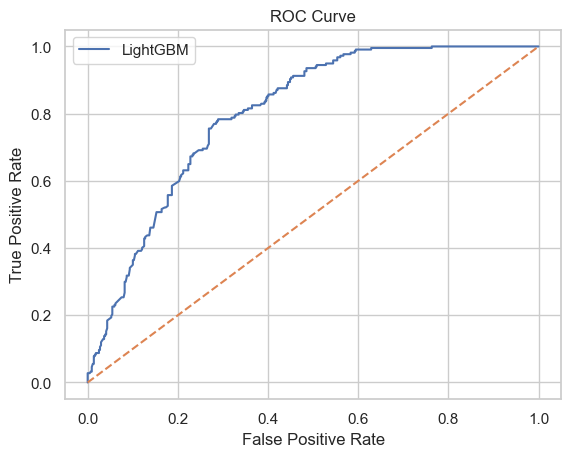

In [60]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_pred_proba = lgb_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr, label="LightGBM")
plt.plot([0,1], [0,1], linestyle='--')  # random model
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [61]:
from sklearn.metrics import roc_auc_score
auc_score = roc_auc_score(y_test, y_pred_proba)
print("LightGBM AUC Score:", auc_score)

LightGBM AUC Score: 0.801974533659448


In [62]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [63]:
# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, test_probs)
auc_xgb = roc_auc_score(y_test, test_probs)

# CatBoost
fpr_cat, tpr_cat, _ = roc_curve(y_test, test_probs_cat)
auc_cat = roc_auc_score(y_test, test_probs_cat)

# LightGBM
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, test_probs_lgb)
auc_lgb = roc_auc_score(y_test, test_probs_lgb)

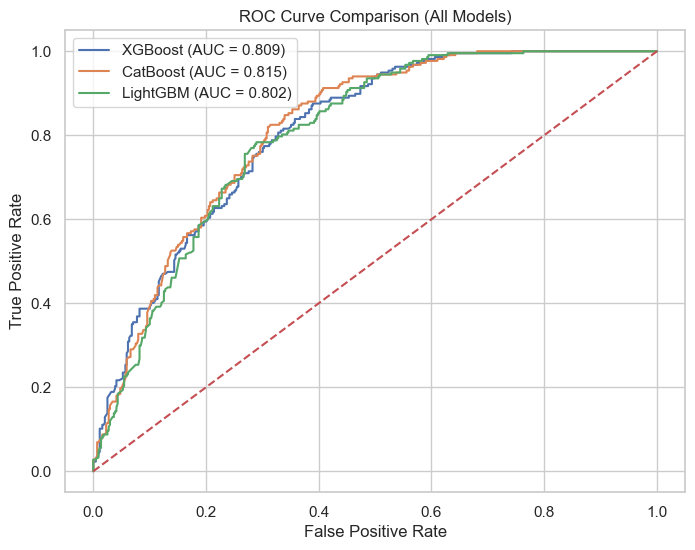

In [64]:
plt.figure(figsize=(8,6))

plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")
plt.plot(fpr_cat, tpr_cat, label=f"CatBoost (AUC = {auc_cat:.3f})")
plt.plot(fpr_lgb, tpr_lgb, label=f"LightGBM (AUC = {auc_lgb:.3f})")

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (All Models)")
plt.legend()
plt.show()

In [65]:
print("XGBoost AUC:", auc_xgb)
print("CatBoost AUC:", auc_cat)
print("LightGBM AUC:", auc_lgb)

XGBoost AUC: 0.8092858717445388
CatBoost AUC: 0.8145240019734838
LightGBM AUC: 0.801974533659448


In [66]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

In [76]:
## Overfitting
# from xgboost import XGBClassifier
# from sklearn.metrics import roc_auc_score, classification_report

# xgb_model = XGBClassifier(
#     n_estimators=500,
#     learning_rate=0.03,
#     max_depth=5,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     scale_pos_weight=scale_pos_weight,
#     random_state=42,
#     eval_metric='logloss'
# )

# xgb_model.fit(X_train, y_train)

# val_probs = xgb_model.predict_proba(X_val)[:, 1]
# test_probs = xgb_model.predict_proba(X_test)[:, 1]

# print("Validation ROC-AUC:", roc_auc_score(y_val, val_probs))
# print("Test ROC-AUC:", roc_auc_score(y_test, test_probs))

# y_pred = xgb_model.predict(X_test)
# print("\nClassification Report:\n")
# print(classification_report(y_test, y_pred))

Validation ROC-AUC: 0.7488636839679947
Test ROC-AUC: 0.8055383517210248

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.70      0.77       439
           1       0.55      0.76      0.64       217

    accuracy                           0.72       656
   macro avg       0.70      0.73      0.70       656
weighted avg       0.76      0.72      0.73       656



In [70]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

params = {
    'n_estimators': [300, 500, 700],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight),
    param_distributions=params,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1}
